In [220]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_validate,GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, loguniform
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import joblib
import sklearn.svm as svm
import matplotlib.pyplot as plt
from sklearn.base import clone

In [221]:
train_set = pd.read_csv("../data/processed/train_set.csv")
test_set = pd.read_csv("../data/processed/test_set.csv")

In [222]:
# Define Features and Target Variable

TARGET = 'price'
X_train = train_set.drop(columns=[TARGET])
y_train = train_set[TARGET]

X_test = test_set.drop(columns = [TARGET])
y_test = test_set[TARGET]

In [223]:
# Feature Preprocessing Pipeline
cat_cols = X_train.select_dtypes(include = ['object', 'category','str']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline (steps=[
    ('imputer', SimpleImputer (strategy= 'constant', fill_value= 'missing') ),
    ('ohe', OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency= 0.01
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, num_cols),
        ('cat', categorical_pipe, cat_cols),
    ],
    remainder = 'drop'
)

In [224]:
# Cross-Validation Evaluation and Experiment Logging

def regression_cv_metrics(model, X, y, cv=5):
  scores = cross_validate(
      model, X, y,
      scoring= {'rmse':'neg_root_mean_squared_error',
                'mae':'neg_mean_absolute_error',
                'mape':'neg_mean_absolute_percentage_error'
                },
      cv =cv,
      n_jobs =-1
  )

  rmse_scores = -scores['test_rmse']
  mae_scores = -scores['test_mae']
  mape_scores = -scores['test_mape']

  return {'rmse_mean': rmse_scores.mean(),
      'rmse_std':rmse_scores.std(),
      'mae_mean':mae_scores.mean(),
      'mae_std': mae_scores.std(),
      'mape_mean': mape_scores.mean(),
      'mape_std':mape_scores.std(),
}

results = []

def log_result(variant, model_name, model_key, rmse_mean,rmse_std,mae_mean,mae_std,mape_mean,mape_std,cv,params=None):
    if params is None:
        params = {}

    results.append({
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M'),
        'variant': variant,
        'model': model_name,
        'model_key': model_key,
        'rmse_mean': rmse_mean,
        'rmse_std': rmse_std,
        'mae_mean': mae_mean,
        'mae_std': mae_std,
        'mape_mean': mape_mean,
        'mape_std': mape_std,
        'cv': cv,
        'params': params
    })

MODEL_REGISTRY = {
    "LinearRegression": LinearRegression,
    "DecisionTreeRegressor": DecisionTreeRegressor,
    "RandomForestRegressor": RandomForestRegressor,
    "SVR": svm.SVR
}


In [225]:
lin_reg = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

cv_folds = 5
metrics = regression_cv_metrics(lin_reg, X_train, y_train, cv=cv_folds)

model_params = lin_reg['model'].get_params()

log_result(
    variant='BaseLine',
    model_name='LinearRegression',
    model_key='lin_reg_baseline',
    rmse_mean=metrics['rmse_mean'],
    rmse_std=metrics['rmse_std'],
    mae_mean=metrics['mae_mean'],
    mae_std=metrics['mae_std'],
    mape_mean=metrics['mape_mean'],
    mape_std=metrics['mape_std'],
    cv=cv_folds,
    params=model_params
)

pd.DataFrame(results).sort_values('rmse_mean')

,timestamp,variant,model,model_key,rmse_mean,rmse_std,mae_mean,mae_std,mape_mean,mape_std,cv,params
0,2026-03-11 17:49,BaseLine,LinearRegression,lin_reg_baseline,7147.805028,25.337156,5234.397852,6.854459,0.515079,0.005371,5,"{'copy_X': True, 'fit_intercept': True, 'n_job..."


In [226]:
# Baseline 2. DecisionTreeRegressor

tree_reg = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

cv_folds = 5
metrics = regression_cv_metrics(tree_reg, X_train, y_train, cv=cv_folds)

model_params = tree_reg['model'].get_params()

log_result(
    variant='BaseLine2',
    model_name='DecisionTreeRegressor',
    model_key='tree_reg_baseline',
    rmse_mean=metrics['rmse_mean'],
    rmse_std=metrics['rmse_std'],
    mae_mean=metrics['mae_mean'],
    mae_std=metrics['mae_std'],
    mape_mean=metrics['mape_mean'],
    mape_std=metrics['mape_std'],
    cv=cv_folds,
    params=model_params
)

pd.DataFrame(results).sort_values('rmse_mean')

,timestamp,variant,model,model_key,rmse_mean,rmse_std,mae_mean,mae_std,mape_mean,mape_std,cv,params
1,2026-03-11 17:51,BaseLine2,DecisionTreeRegressor,tree_reg_baseline,5276.646764,28.057011,2319.524621,22.414052,0.223143,0.003674,5,"{'ccp_alpha': 0.0, 'criterion': 'squared_error..."
0,2026-03-11 17:49,BaseLine,LinearRegression,lin_reg_baseline,7147.805028,25.337156,5234.397852,6.854459,0.515079,0.005371,5,"{'copy_X': True, 'fit_intercept': True, 'n_job..."


In [227]:
rf_reg = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_estimators=50,
        max_depth=20,
        min_samples_leaf=5,
        n_jobs=-1
    ))
])

cv_folds = 5
metrics = regression_cv_metrics(rf_reg, X_train, y_train, cv=cv_folds)

model_params = rf_reg['model'].get_params()

log_result(
    variant='BaseLine 3',
    model_name='RandomForestRegressor',
    model_key='rf_reg_baseline',
    rmse_mean=metrics['rmse_mean'],
    rmse_std=metrics['rmse_std'],
    mae_mean=metrics['mae_mean'],
    mae_std=metrics['mae_std'],
    mape_mean=metrics['mape_mean'],
    mape_std=metrics['mape_std'],
    cv=cv_folds,
    params=model_params
)

pd.DataFrame(results).sort_values('rmse_mean')

,timestamp,variant,model,model_key,rmse_mean,rmse_std,mae_mean,mae_std,mape_mean,mape_std,cv,params
2,2026-03-11 18:01,BaseLine 3,RandomForestRegressor,rf_reg_baseline,4896.218549,36.943654,3035.891829,12.137614,0.280480,0.003797,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
1,2026-03-11 17:51,BaseLine2,DecisionTreeRegressor,tree_reg_baseline,5276.646764,28.057011,2319.524621,22.414052,0.223143,0.003674,5,"{'ccp_alpha': 0.0, 'criterion': 'squared_error..."
0,2026-03-11 17:49,BaseLine,LinearRegression,lin_reg_baseline,7147.805028,25.337156,5234.397852,6.854459,0.515079,0.005371,5,"{'copy_X': True, 'fit_intercept': True, 'n_job..."


In [228]:
rf_reg = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_estimators=100,
        max_depth=30,
        min_samples_leaf=2,
        n_jobs=-1
    ))
])

cv_folds = 5
metrics = regression_cv_metrics(rf_reg, X_train, y_train, cv=cv_folds)

model_params = rf_reg['model'].get_params()

log_result(
    variant='BaseLine 4',
    model_name='RandomForestRegressor',
    model_key='rf_reg_deeper',
    rmse_mean=metrics['rmse_mean'],
    rmse_std=metrics['rmse_std'],
    mae_mean=metrics['mae_mean'],
    mae_std=metrics['mae_std'],
    mape_mean=metrics['mape_mean'],
    mape_std=metrics['mape_std'],
    cv=cv_folds,
    params=model_params
)

pd.DataFrame(results).sort_values('rmse_mean')

,timestamp,variant,model,model_key,rmse_mean,rmse_std,mae_mean,mae_std,mape_mean,mape_std,cv,params
3,2026-03-11 18:42,BaseLine 4,RandomForestRegressor,rf_reg_deeper,4191.447786,38.796376,2316.676717,11.934988,0.224306,0.003345,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
2,2026-03-11 18:01,BaseLine 3,RandomForestRegressor,rf_reg_baseline,4896.218549,36.943654,3035.891829,12.137614,0.280480,0.003797,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
1,2026-03-11 17:51,BaseLine2,DecisionTreeRegressor,tree_reg_baseline,5276.646764,28.057011,2319.524621,22.414052,0.223143,0.003674,5,"{'ccp_alpha': 0.0, 'criterion': 'squared_error..."
0,2026-03-11 17:49,BaseLine,LinearRegression,lin_reg_baseline,7147.805028,25.337156,5234.397852,6.854459,0.515079,0.005371,5,"{'copy_X': True, 'fit_intercept': True, 'n_job..."


In [229]:
rf_reg = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        random_state=80,
        n_estimators=150,
        max_depth=40,
        min_samples_leaf=1,
        n_jobs=7
    ))
])

cv_folds = 5
metrics = regression_cv_metrics(rf_reg, X_train, y_train, cv=cv_folds)

model_params = rf_reg['model'].get_params()

log_result(
    variant='BaseLine 5',
    model_name='RandomForestRegressor',
    model_key='rf_reg_deeper_v2',
    rmse_mean=metrics['rmse_mean'],
    rmse_std=metrics['rmse_std'],
    mae_mean=metrics['mae_mean'],
    mae_std=metrics['mae_std'],
    mape_mean=metrics['mape_mean'],
    mape_std=metrics['mape_std'],
    cv=cv_folds,
    params=model_params
)

pd.DataFrame(results).sort_values('rmse_mean')

,timestamp,variant,model,model_key,rmse_mean,rmse_std,mae_mean,mae_std,mape_mean,mape_std,cv,params
4,2026-03-11 20:16,BaseLine 5,RandomForestRegressor,rf_reg_deeper_v2,3980.694852,43.382908,2043.813668,15.047489,0.202800,0.003329,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
3,2026-03-11 18:42,BaseLine 4,RandomForestRegressor,rf_reg_deeper,4191.447786,38.796376,2316.676717,11.934988,0.224306,0.003345,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
2,2026-03-11 18:01,BaseLine 3,RandomForestRegressor,rf_reg_baseline,4896.218549,36.943654,3035.891829,12.137614,0.280480,0.003797,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
1,2026-03-11 17:51,BaseLine2,DecisionTreeRegressor,tree_reg_baseline,5276.646764,28.057011,2319.524621,22.414052,0.223143,0.003674,5,"{'ccp_alpha': 0.0, 'criterion': 'squared_error..."
0,2026-03-11 17:49,BaseLine,LinearRegression,lin_reg_baseline,7147.805028,25.337156,5234.397852,6.854459,0.515079,0.005371,5,"{'copy_X': True, 'fit_intercept': True, 'n_job..."


In [230]:
# Support Vector Regression

X_train_svr = X_train.iloc[:50000].copy()
y_train_svr = y_train.iloc[:50000].copy()

svr_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', svm.SVR())
])

param_distributions = [
    {
        'model__kernel': ['linear'],
        'model__C': loguniform(1, 1000)
    },
    {
        'model__kernel': ['rbf'],
        'model__C': loguniform(1, 1000),
        'model__gamma': loguniform(1e-4, 1e-1)
    }
]

svr_search = RandomizedSearchCV(
    svr_pipe,
    param_distributions,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

svr_search.fit(X_train_svr, y_train_svr)

print("Best params:", svr_search.best_params_)
print("Best RMSE:", -svr_search.best_score_)

svr_metrics = regression_cv_metrics(
    svr_search.best_estimator_,
    X_train_svr,
    y_train_svr,
    cv=3
)

log_result(
    variant='Tuned',
    model_name='SVR',
    model_key='svr_random_search',
    rmse_mean=svr_metrics['rmse_mean'],
    rmse_std=svr_metrics['rmse_std'],
    mae_mean=svr_metrics['mae_mean'],
    mae_std=svr_metrics['mae_std'],
    mape_mean=svr_metrics['mape_mean'],
    mape_std=svr_metrics['mape_std'],
    cv=3,
    params=svr_search.best_params_
)

pd.DataFrame(results).sort_values('rmse_mean')

Best params: {'model__C': np.float64(146.55354118727698), 'model__gamma': np.float64(0.06541210527692734), 'model__kernel': 'rbf'}
Best RMSE: 7003.2719847363705


,timestamp,variant,model,model_key,rmse_mean,rmse_std,mae_mean,mae_std,mape_mean,mape_std,cv,params
4,2026-03-11 20:16,BaseLine 5,RandomForestRegressor,rf_reg_deeper_v2,3980.694852,43.382908,2043.813668,15.047489,0.202800,0.003329,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
3,2026-03-11 18:42,BaseLine 4,RandomForestRegressor,rf_reg_deeper,4191.447786,38.796376,2316.676717,11.934988,0.224306,0.003345,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
2,2026-03-11 18:01,BaseLine 3,RandomForestRegressor,rf_reg_baseline,4896.218549,36.943654,3035.891829,12.137614,0.280480,0.003797,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
1,2026-03-11 17:51,BaseLine2,DecisionTreeRegressor,tree_reg_baseline,5276.646764,28.057011,2319.524621,22.414052,0.223143,0.003674,5,"{'ccp_alpha': 0.0, 'criterion': 'squared_error..."
5,2026-03-11 20:26,Tuned,SVR,svr_random_search,7003.271985,13.217080,4664.330400,24.605210,0.371454,0.004135,3,"{'model__C': 146.55354118727698, 'model__gamma..."
0,2026-03-11 17:49,BaseLine,LinearRegression,lin_reg_baseline,7147.805028,25.337156,5234.397852,6.854459,0.515079,0.005371,5,"{'copy_X': True, 'fit_intercept': True, 'n_job..."


In [ ]:
# Randomized Search Over Preprocessing and Model Parameters
rf_reg = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=1))
])

param_distributions = {
    'preprocess__num__imputer__strategy': ['median', 'most_frequent'],
    'preprocess__num__imputer__add_indicator': [True, False],
    'preprocess__cat__ohe__min_frequency': [0.005, 0.01, 0.02],
    'model__n_estimators': randint(50, 150),
    'model__max_depth': randint(15, 35),
    'model__min_samples_leaf': randint(1, 6)
}

rand_search_prep = RandomizedSearchCV(
    rf_reg,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

rand_search_prep.fit(X_train, y_train)

print("Best params:", rand_search_prep.best_params_)
print("Best RMSE:", -rand_search_prep.best_score_)

prep_metrics = regression_cv_metrics(
    rand_search_prep.best_estimator_,
    X_train,
    y_train,
    cv=5
)

log_result(
    variant='Tuned',
    model_name='RandomForestRegressor',
    model_key='rf_reg_prep_random_search',
    rmse_mean=prep_metrics['rmse_mean'],
    rmse_std=prep_metrics['rmse_std'],
    mae_mean=prep_metrics['mae_mean'],
    mae_std=prep_metrics['mae_std'],
    mape_mean=prep_metrics['mape_mean'],
    mape_std=prep_metrics['mape_std'],
    cv=5,
    params=rand_search_prep.best_params_
)

pd.DataFrame(results).sort_values('rmse_mean')

In [ ]:
# Randomized Hyperparameter Night_time Search

param_distributions = {
    'model__n_estimators': randint(100, 600),
    'model__max_depth': randint(10, 80),
    'model__min_samples_leaf': randint(1, 10),
    'model__max_features': loguniform(0.2, 1.0),
    'model__min_samples_split': randint(2, 20)
}

rand_search = RandomizedSearchCV(
    rf_reg,
    param_distributions=param_distributions,
    n_iter=40,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

rand_search.fit(X_train, y_train)

print('Best params:', rand_search.best_params_)
print('Best RMSE:', -rand_search.best_score_)

rand_metrics = regression_cv_metrics(
    rand_search.best_estimator_,
    X_train,
    y_train,
    cv=5
)

log_result(
    variant='Tuned',
    model_name='RandomForestRegressor',
    model_key='rf_reg_random_search_night',
    rmse_mean=rand_metrics['rmse_mean'],
    rmse_std=rand_metrics['rmse_std'],
    mae_mean=rand_metrics['mae_mean'],
    mae_std=rand_metrics['mae_std'],
    mape_mean=rand_metrics['mape_mean'],
    mape_std=rand_metrics['mape_std'],
    cv=5,
    params=rand_search.best_params_
)

pd.DataFrame(results).sort_values('rmse_mean')

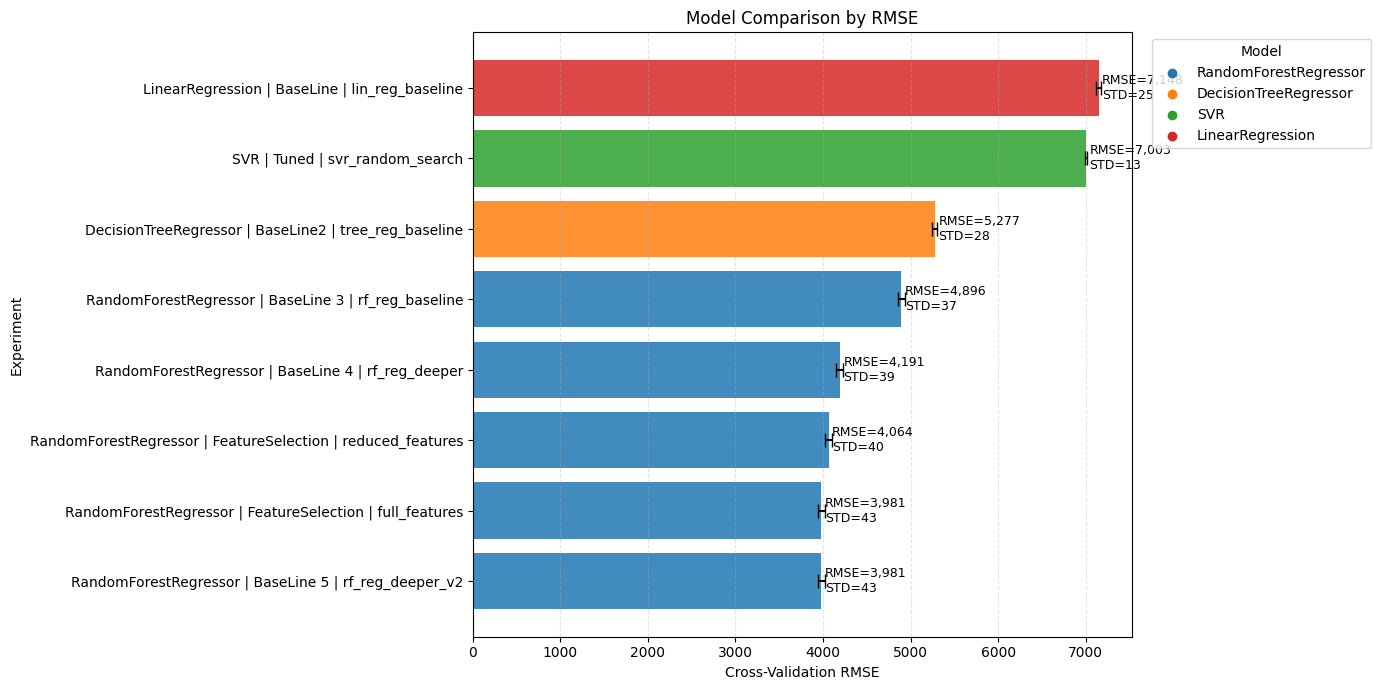

In [269]:
import pandas as pd
import matplotlib.pyplot as plt

plot_df = pd.DataFrame(results).copy()
plot_df = plot_df[plot_df["cv"] != "test"].copy()

plot_df["label"] = (
    plot_df["model"] + " | " +
    plot_df["variant"] + " | " +
    plot_df["model_key"]
)

plot_df = plot_df.sort_values("rmse_mean", ascending=True).reset_index(drop=True)

models = plot_df["model"].unique()
color_map = {model: f"C{i}" for i, model in enumerate(models)}
bar_colors = plot_df["model"].map(color_map)

plt.figure(figsize=(14, 7))

bars = plt.barh(
    plot_df["label"],
    plot_df["rmse_mean"],
    xerr=plot_df["rmse_std"].fillna(0),
    capsize=5,
    alpha=0.85,
    color=bar_colors
)

for i, row in plot_df.iterrows():
    plt.text(
        row["rmse_mean"] + 40,
        i,
        f'RMSE={row["rmse_mean"]:,.0f}\nSTD={row["rmse_std"]:,.0f}',
        va="center",
        fontsize=9
    )

plt.xlabel("Cross-Validation RMSE")
plt.ylabel("Experiment")
plt.title("Model Comparison by RMSE")
plt.grid(axis="x", linestyle="--", alpha=0.35)

for model, color in color_map.items():
    plt.scatter([], [], color=color, label=model)

plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [232]:
results_df = pd.DataFrame(results)

best_row = results_df.loc[results_df['rmse_mean'].idxmin()]
best_model_name = best_row['model']
best_model_key = best_row['model_key']
best_params = best_row['params']

model_class = MODEL_REGISTRY[best_model_name]

final_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', model_class(**best_params))
])


In [233]:
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [234]:
# importances from the model
feature_importances = final_model.named_steps['model'].feature_importances_

feature_names = final_model.named_steps['preprocess'].get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

In [235]:
importance_df

,feature,importance
2,num__car_age,0.225037
0,num__year,0.218271
1,num__odometer,0.102141
49,cat__drive_fwd,0.082225
35,cat__fuel_diesel,0.075641
...,...,...
56,cat__type_mini-van,0.000346
37,cat__fuel_hybrid,0.000326
87,cat__state_ky,0.000312
89,cat__state_md,0.000307


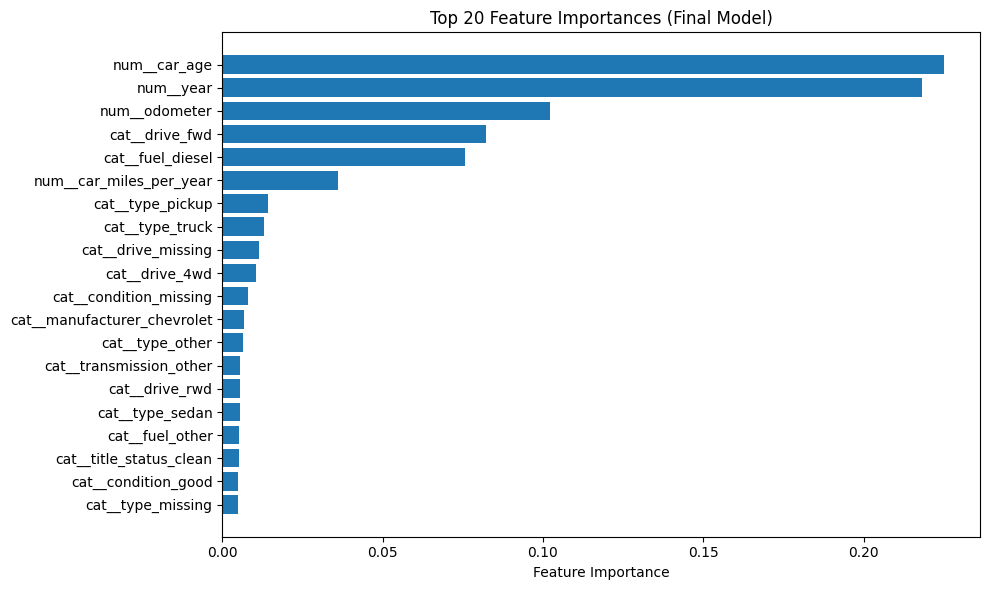

In [236]:
top_n = 20
top_features = importance_df.head(top_n)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['feature'][::-1],
    top_features['importance'][::-1]
)

plt.xlabel("Feature Importance")
plt.title("Top 20 Feature Importances (Final Model)")
plt.tight_layout()

plt.show()

In [237]:
selector = SelectFromModel(
    final_model.named_steps['model'],
    threshold='median',
    prefit=True
)

X_train_transformed = final_model.named_steps['preprocess'].transform(X_train)
X_train_reduced = selector.transform(X_train_transformed)

In [238]:
selected_mask = selector.get_support()

selected_features = feature_names[selected_mask]

selected_features

array(['num__year', 'num__odometer', 'num__car_age',
       'num__car_miles_per_year', 'cat__manufacturer_audi',
       'cat__manufacturer_bmw', 'cat__manufacturer_cadillac',
       'cat__manufacturer_chevrolet', 'cat__manufacturer_ford',
       'cat__manufacturer_gmc', 'cat__manufacturer_hyundai',
       'cat__manufacturer_jeep', 'cat__manufacturer_lexus',
       'cat__manufacturer_mercedes-benz', 'cat__manufacturer_missing',
       'cat__manufacturer_nissan', 'cat__manufacturer_ram',
       'cat__manufacturer_subaru', 'cat__manufacturer_toyota',
       'cat__manufacturer_volkswagen',
       'cat__manufacturer_infrequent_sklearn', 'cat__condition_excellent',
       'cat__condition_good', 'cat__condition_like new',
       'cat__condition_missing', 'cat__fuel_diesel', 'cat__fuel_other',
       'cat__title_status_clean', 'cat__transmission_automatic',
       'cat__transmission_other', 'cat__drive_4wd', 'cat__drive_fwd',
       'cat__drive_missing', 'cat__drive_rwd', 'cat__type_SUV',
    

In [239]:
print("Original features:", len(feature_names))
print("Selected features:", len(selected_features))

Original features: 108
Selected features: 54


In [240]:
# clone model
reduced_model = clone(final_model.named_steps['model'])

reduced_model.fit(X_train_reduced, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",40
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [241]:
full_estimator = clone(final_model.named_steps['model'])
reduced_estimator = clone(final_model.named_steps['model'])

full_cv_metrics = regression_cv_metrics(full_estimator, X_train_transformed, y_train, cv=5)
reduced_cv_metrics = regression_cv_metrics(reduced_estimator, X_train_reduced, y_train, cv=5)

In [242]:
log_result(
    variant='FeatureSelection',
    model_name=best_model_name,
    model_key='full_features',
    rmse_mean=full_cv_metrics['rmse_mean'],
    rmse_std=full_cv_metrics['rmse_std'],
    mae_mean=full_cv_metrics['mae_mean'],
    mae_std=full_cv_metrics['mae_std'],
    mape_mean=full_cv_metrics['mape_mean'],
    mape_std=full_cv_metrics['mape_std'],
    cv=5,
    params=best_params
)

log_result(
    variant='FeatureSelection',
    model_name=best_model_name,
    model_key='reduced_features',
    rmse_mean=reduced_cv_metrics['rmse_mean'],
    rmse_std=reduced_cv_metrics['rmse_std'],
    mae_mean=reduced_cv_metrics['mae_mean'],
    mae_std=reduced_cv_metrics['mae_std'],
    mape_mean=reduced_cv_metrics['mape_mean'],
    mape_std=reduced_cv_metrics['mape_std'],
    cv=5,
    params=best_params
)

results_df = pd.DataFrame(results).sort_values('rmse_mean')

In [243]:
results_df

,timestamp,variant,model,model_key,rmse_mean,rmse_std,mae_mean,mae_std,mape_mean,mape_std,cv,params
4,2026-03-11 20:16,BaseLine 5,RandomForestRegressor,rf_reg_deeper_v2,3980.694852,43.382908,2043.813668,15.047489,0.202800,0.003329,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
6,2026-03-11 23:49,FeatureSelection,RandomForestRegressor,full_features,3980.948829,43.447293,2043.800882,15.062610,0.202808,0.003341,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
7,2026-03-11 23:49,FeatureSelection,RandomForestRegressor,reduced_features,4064.067946,40.146050,2055.092816,14.518135,0.208812,0.003572,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
3,2026-03-11 18:42,BaseLine 4,RandomForestRegressor,rf_reg_deeper,4191.447786,38.796376,2316.676717,11.934988,0.224306,0.003345,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
2,2026-03-11 18:01,BaseLine 3,RandomForestRegressor,rf_reg_baseline,4896.218549,36.943654,3035.891829,12.137614,0.280480,0.003797,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
1,2026-03-11 17:51,BaseLine2,DecisionTreeRegressor,tree_reg_baseline,5276.646764,28.057011,2319.524621,22.414052,0.223143,0.003674,5,"{'ccp_alpha': 0.0, 'criterion': 'squared_error..."
5,2026-03-11 20:26,Tuned,SVR,svr_random_search,7003.271985,13.217080,4664.330400,24.605210,0.371454,0.004135,3,"{'model__C': 146.55354118727698, 'model__gamma..."
0,2026-03-11 17:49,BaseLine,LinearRegression,lin_reg_baseline,7147.805028,25.337156,5234.397852,6.854459,0.515079,0.005371,5,"{'copy_X': True, 'fit_intercept': True, 'n_job..."


In [244]:
best_row = results_df.loc[results_df['rmse_mean'].idxmin()]
best_variant = best_row['model_key']

In [245]:
if best_variant == 'full_features':

    final_pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', clone(final_model.named_steps['model']))
    ])

    final_pipeline.fit(X_train, y_train)
else:

    final_pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('selector', selector),
        ('model', clone(final_model.named_steps['model']))
    ])

    final_pipeline.fit(X_train, y_train)

In [246]:
test_predictions = final_pipeline.predict(X_test)

In [247]:
final_rmse = root_mean_squared_error(y_test, test_predictions)
final_mae = mean_absolute_error(y_test, test_predictions)
final_mape = mean_absolute_percentage_error(y_test, test_predictions)

In [248]:
print("Final Model Performance")
print(f"Model variant: {best_variant}")
print(f"RMSE: {final_rmse:,.2f}")
print(f"MAE: {final_mae:,.2f}")
print(f"MAPE: {final_mape:.4f}")
log_result(
    variant='FinalTest',
    model_name=best_model_name,
    model_key=best_variant,
    rmse_mean=final_rmse,
    rmse_std=0,
    mae_mean=final_mae,
    mae_std=0,
    mape_mean=final_mape,
    mape_std=0,
    cv='test',
    params=best_params
)

results_df = pd.DataFrame(results).sort_values('rmse_mean')
results_df

Final Model Performance
Model variant: rf_reg_deeper_v2
RMSE: 3,889.79
MAE: 1,891.89
MAPE: 0.1971


,timestamp,variant,model,model_key,rmse_mean,rmse_std,mae_mean,mae_std,mape_mean,mape_std,cv,params
8,2026-03-12 00:07,FinalTest,RandomForestRegressor,rf_reg_deeper_v2,3889.789206,0.000000,1891.894311,0.000000,0.197109,0.000000,test,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
4,2026-03-11 20:16,BaseLine 5,RandomForestRegressor,rf_reg_deeper_v2,3980.694852,43.382908,2043.813668,15.047489,0.202800,0.003329,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
6,2026-03-11 23:49,FeatureSelection,RandomForestRegressor,full_features,3980.948829,43.447293,2043.800882,15.062610,0.202808,0.003341,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
7,2026-03-11 23:49,FeatureSelection,RandomForestRegressor,reduced_features,4064.067946,40.146050,2055.092816,14.518135,0.208812,0.003572,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
3,2026-03-11 18:42,BaseLine 4,RandomForestRegressor,rf_reg_deeper,4191.447786,38.796376,2316.676717,11.934988,0.224306,0.003345,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
2,2026-03-11 18:01,BaseLine 3,RandomForestRegressor,rf_reg_baseline,4896.218549,36.943654,3035.891829,12.137614,0.280480,0.003797,5,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri..."
1,2026-03-11 17:51,BaseLine2,DecisionTreeRegressor,tree_reg_baseline,5276.646764,28.057011,2319.524621,22.414052,0.223143,0.003674,5,"{'ccp_alpha': 0.0, 'criterion': 'squared_error..."
5,2026-03-11 20:26,Tuned,SVR,svr_random_search,7003.271985,13.217080,4664.330400,24.605210,0.371454,0.004135,3,"{'model__C': 146.55354118727698, 'model__gamma..."
0,2026-03-11 17:49,BaseLine,LinearRegression,lin_reg_baseline,7147.805028,25.337156,5234.397852,6.854459,0.515079,0.005371,5,"{'copy_X': True, 'fit_intercept': True, 'n_job..."


In [249]:
joblib.dump(final_pipeline, "../models/used_car_price_model.joblib")

['../models/used_car_price_model.joblib']

In [272]:
model = joblib.load("../models/used_car_price_model.joblib")

In [273]:
new_car = pd.DataFrame({
    "year": [2017],
    "manufacturer": ["ford"],
    "model": ['wrx'],
    "odometer": [15000],
    "fuel": ["gas"],
    "transmission": ["manual"],
    "title_status": ['clean'],
    "car_age": [None],
    "drive": ['awd'],
    "car_miles_per_year": [None],
    "type": ["sedan"],
    "condition": ["good"],
    "state": ["fl"],
    "paint_color": ["black"]
})

In [274]:
prediction = model.predict(new_car)

print(prediction)

[32364.28]
